# Aplicando técnicas de otimização de hiperparâmetros para melhorar o desempenho do modelo de predição de resistência

In [60]:
%%capture
!pip install pymoo scipy

In [65]:
from pymoo.core.problem import ElementwiseProblem
from scipy.interpolate import PchipInterpolator
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import pandas as pd
import numpy as np
import os


In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
def get_lims(X):
    return X.min(axis=0), X.max(axis=0)

In [49]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies'

model_path = os.path.join(dirpath, "melhor_modelo_resistencia.json")
data_path = os.path.join(dirpath, 'df_analise.pkl')
model = XGBRegressor()
model.load_model(model_path)
df = pd.read_pickle(data_path)
feature_names = df.drop(columns=['resistencia', 'bins']).columns.tolist()

In [52]:
min_lim, max_lim = get_lims(df[feature_names].values)
min_lim[-1] = 28
max_lim[-1] = 28

print("Limites mínimos:", min_lim)
print("Limites máximos:", max_lim)
print(min_lim.shape)
print(max_lim.shape)

Limites mínimos: [102.    0.    0.  121.8   0.  801.  594.   28. ]
Limites máximos: [ 540.   359.4  200.1  247.    32.2 1145.   992.6   28. ]
(8,)
(8,)


In [53]:
class ResistenciaOptimization(ElementwiseProblem):

    def __init__(self, xgb_model, feature_names):

        self.xgb_model = xgb_model
        self.feature_names = feature_names

        xl = min_lim
        xu = max_lim

        super().__init__(
            n_var=8,
            n_obj=2,
            n_constr=0,
            xl=xl,
            xu=xu
        )

    def _evaluate(self, x, out, *args, **kwargs):

        prediction = self.xgb_model.predict(
            x.reshape(1, -1)
        )[0]

        cimento = x[0]
        escoria = x[1]
        cinza = x[2]
        agua = x[3]
        superplastificante = x[4]
        brita = x[5]
        areia = x[6]

        custo = (
            cimento * 0.40 +
            escoria * 0.20 +
            cinza * 0.18 +
            agua * 0.01 +
            superplastificante * 4.00 +
            brita * 0.05 +
            areia * 0.04
        )

        out["F"] = [
            custo,
            -prediction
        ]

In [69]:
class ReceitaPorResistencia(ElementwiseProblem):

    def __init__(self, xgb_model, target_value):

        self.xgb_model = xgb_model
        self.target_value = target_value

        xl = min_lim
        xu = max_lim

        super().__init__(
            n_var=8,
            n_obj=2,
            n_constr=0,
            xl=xl,
            xu=xu
        )

    def _evaluate(self, x, out, *args, **kwargs):

        # -------------------------------
        # predição
        # -------------------------------

        input_data = x.reshape(1, -1).astype(np.float32)

        prediction = self.xgb_model.predict(
            input_data
        )[0]

        # -------------------------------
        # objetivo 1
        # erro da resistência
        # -------------------------------

        erro = np.abs(
            prediction - self.target_value
        )

        # -------------------------------
        # objetivo 2
        # custo
        # -------------------------------

        cimento = x[0]
        escoria = x[1]
        cinza = x[2]
        agua = x[3]
        superplastificante = x[4]
        brita = x[5]
        areia = x[6]

        custo = (
            cimento * 0.40 +
            escoria * 0.20 +
            cinza * 0.18 +
            agua * 0.01 +
            superplastificante * 4.00 +
            brita * 0.05 +
            areia * 0.04
        )

        # -------------------------------
        # objetivos
        # -------------------------------

        out["F"] = [
            erro,
            custo
        ]

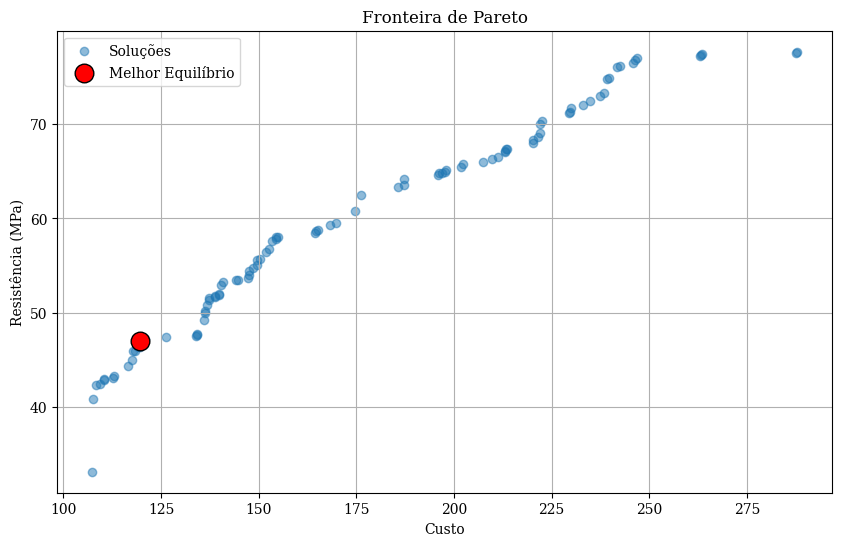

Melhor resistência: 46.96 MPa
Custo: 119.61

Receita ótima:

cimento: 102.11
escoriadealtoforno: 49.18
cinzasvolantes: 1.80
agua: 143.40
superplastificante: 0.02
agregadogrosso: 824.04
agregadofino: 647.56
idade: 28.00


In [88]:
problem = ResistenciaOptimization(
    model,
    feature_names=feature_names
)

algorithm = NSGA2(
    pop_size=100
)

res = minimize(problem,
               algorithm,
               ('n_gen', 50),
               seed=42,
               verbose=False)

F = res.F.copy()

# ---------------------------------------
# inverter resistência
# ---------------------------------------

F[:,1] = -F[:,1]

# ---------------------------------------
# normalização
# ---------------------------------------

F_norm = F.copy()

F_norm[:,0] = (
    F[:,0] / F[:,0].max()
)

# resistência:
# queremos MAXIMIZAR
# então invertimos a lógica

F_norm[:,1] = (
    1 - (F[:,1] / F[:,1].max())
)

# ---------------------------------------
# score equilíbrio
# ---------------------------------------

score = np.sqrt(
    F_norm[:,0]**2 +
    F_norm[:,1]**2
)

best_idx = np.argmin(score)

# ---------------------------------------
# melhor solução
# ---------------------------------------

best_x = res.X[best_idx]

pred = model.predict(
    best_x.reshape(1, -1)
)[0]

# ---------------------------------------
# plot
# ---------------------------------------

plt.figure(figsize=(10,6))

# todas soluções
plt.scatter(
    F[:,0],
    F[:,1],
    alpha=0.5,
    label='Soluções'
)

# melhor equilíbrio
plt.scatter(
    F[best_idx,0],
    F[best_idx,1],
    color='red',
    s=180,
    edgecolors='black',
    label='Melhor Equilíbrio'
)

plt.xlabel("Custo")
plt.ylabel("Resistência (MPa)")

plt.title("Fronteira de Pareto")

plt.grid(True)
plt.legend()

plt.show()

# ---------------------------------------
# resultados
# ---------------------------------------

print(f"Melhor resistência: {pred:.2f} MPa")

print(f"Custo: {F[best_idx,0]:.2f}")

print("\nReceita ótima:\n")

for nome, valor in zip(feature_names, best_x):
    print(f"{nome}: {valor:.2f}")

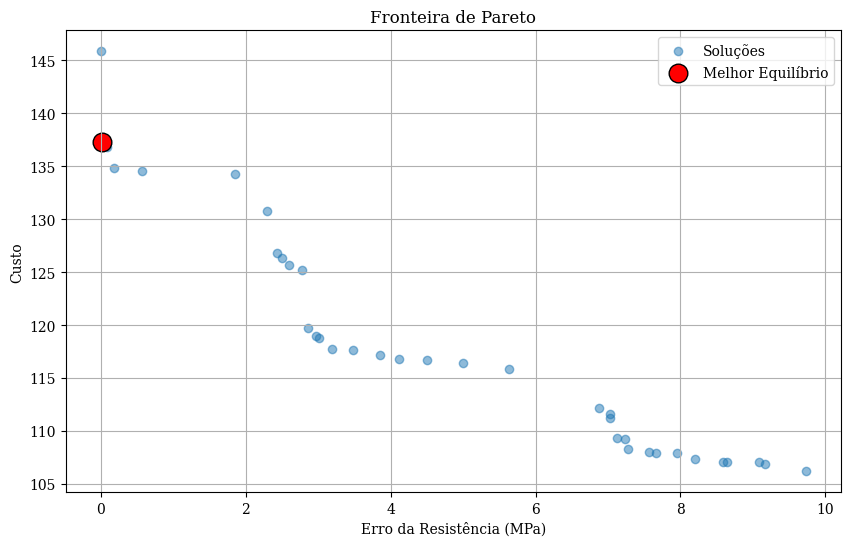

Alvo desejado: 50.00 MPa
Resistência prevista: 50.01 MPa
Erro: 0.0107 MPa
Custo: 137.26

Melhor Receita:

cimento: 171.48
escoriadealtoforno: 0.59
cinzasvolantes: 0.08
agua: 141.38
superplastificante: 0.00
agregadogrosso: 828.08
agregadofino: 642.71
idade: 28.00


In [87]:
target_desejado = 50.0
problem = ReceitaPorResistencia(model, target_desejado)
res = minimize(problem, algorithm, ('n_gen', 50), seed=42)

F = res.F.copy()

# -------------------------------------
# score balanceado
# -------------------------------------

score = (
    F[:,0] / F[:,0].max() +
    F[:,1] / F[:,1].max()
)

best_idx = np.argmin(score)

best_x = res.X[best_idx]

pred = model.predict(
    best_x.reshape(1, -1)
)[0]

# -------------------------------------
# plot
# -------------------------------------

plt.figure(figsize=(10,6))

# todas soluções
plt.scatter(
    F[:,0],   # erro
    F[:,1],   # custo
    alpha=0.5,
    label='Soluções'
)

# melhor equilíbrio
plt.scatter(
    F[best_idx,0],
    F[best_idx,1],
    color='red',
    s=180,
    edgecolors='black',
    label='Melhor Equilíbrio'
)

plt.xlabel("Erro da Resistência (MPa)")
plt.ylabel("Custo")

plt.title("Fronteira de Pareto")

plt.grid(True)
plt.legend()

plt.show()

# -------------------------------------
# resultados
# -------------------------------------

print(f"Alvo desejado: {target_desejado:.2f} MPa")

print(f"Resistência prevista: {pred:.2f} MPa")

print(f"Erro: {F[best_idx,0]:.4f} MPa")

print(f"Custo: {F[best_idx,1]:.2f}")

print("\nMelhor Receita:\n")

for nome, valor in zip(feature_names, best_x):
    print(f"{nome}: {valor:.2f}")